# 1. Import các thư viện cần thiết và cấu hình đồ họa

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [18]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 2. Cấu hình đường dẫn dữ liệu

In [19]:
DATA_DIR = '../data/raw'
TRAIN_PATH = os.path.join(DATA_DIR, 'Train/Monthly-train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'Test/Monthly-test.csv')
INFO_PATH = os.path.join(DATA_DIR, 'M4-info.csv')

print(f'Train data path: {TRAIN_PATH}')
print(f'Test data path: {TEST_PATH}')
print(f'Data Info path: {INFO_PATH}')

Train data path: ../data/raw/Train/Monthly-train.csv
Test data path: ../data/raw/Test/Monthly-test.csv
Data Info path: ../data/raw/M4-info.csv


# 3. Đọc và khám phá dữ liệu thô (Wide Format)

In [29]:
print('Loading train data...')

# Read the first 500 rows
train_wide = pd.read_csv(TRAIN_PATH)
test_wide = pd.read_csv(TEST_PATH)
info_df = pd.read_csv(INFO_PATH)

# Change the first col to unique_id
train_wide.rename(columns={train_wide.columns[0]: 'unique_id'}, inplace=True)
test_wide.rename(columns={test_wide.columns[0]: 'unique_id'}, inplace=True)

print('\n--- TRAIN DATA INFO (WIDE FORMAT) ---')
print(f'Full data size: {train_wide.shape}')
print('First 5 rows:')
print(train_wide.head())

Loading train data...

--- TRAIN DATA INFO (WIDE FORMAT) ---
Full data size: (48000, 2795)
First 5 rows:
  unique_id      V2      V3      V4      V5      V6      V7      V8      V9  \
0        M1  8000.0  8350.0  8570.0  7700.0  7080.0  6520.0  6070.0  6650.0   
1        M2  2440.0  2490.0  2710.0  2290.0  1960.0  1990.0  1960.0  2530.0   
2        M3  2670.0  2590.0  2784.0  2816.0  2888.0  2906.0  2839.0  2860.0   
3        M4  7264.0  7215.0  7022.0  7040.0  6966.0  6984.0  7025.0  7082.0   
4        M5  4210.0  4290.0  4250.0  4320.0  4320.0  4330.0  4320.0  4260.0   

      V10  ...  V2786  V2787  V2788  V2789  V2790  V2791  V2792  V2793  V2794  \
0  6830.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
1  2640.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
2  2798.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
3  6956.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
4  4220.0  ... 

In [30]:
# Kiểm tra horizon của test set (Monthly phải = 18)
horizon = test_wide.shape[1] - 1  # trừ cột unique_id
print(f"Horizon phát hiện trong test set: {horizon}")
assert horizon == 18, f"Cảnh báo: horizon không khớp 18, đang là {horizon}"

Horizon phát hiện trong test set: 18


# 4. Phân tích độ dài các chuỗi thời gian (Series Length)

In [21]:
# Calculate real lengths of each time-series sample (by removing NaN values at the end of each row)
series_lengths = []

for idx, row in train_wide.set_index('unique_id').iterrows():
    # Removing NaN values 
    actual_series = row.dropna()
    series_lengths.append({
        'unique_id': idx,
        'length': len(actual_series)
    })

lengths_df = pd.DataFrame(series_lengths)

# Descriptive statistics about series lengths
print('\n--- TIME-SERIES LENGTHS STATISTICS')
print(lengths_df['length'].describe())


--- TIME-SERIES LENGTHS STATISTICS
count    48000.000000
mean       216.300229
std        137.406295
min         42.000000
25%         82.000000
50%        202.000000
75%        306.000000
max       2794.000000
Name: length, dtype: float64


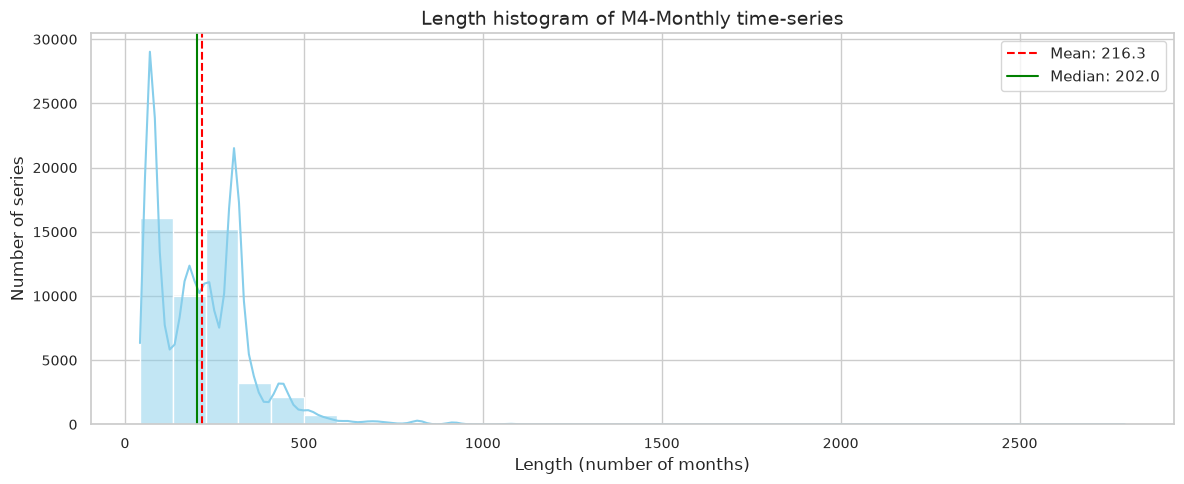

In [22]:
# Draw series lengths histogram
plt.figure(figsize=(12, 5))
sns.histplot(lengths_df['length'], bins=30, kde=True, color='skyblue')
plt.axvline(lengths_df['length'].mean(), color='red', linestyle='--', label=f"Mean: {lengths_df['length'].mean():.1f}")
plt.axvline(lengths_df['length'].median(), color='green', linestyle='-', label=f"Median: {lengths_df['length'].median():.1f}")
plt.title("Length histogram of M4-Monthly time-series")
plt.xlabel("Length (number of months)")
plt.ylabel("Number of series")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Thống kê quartile để làm căn cứ chia length_group và chọn ngưỡng lọc
quantiles = lengths_df['length'].quantile([0.25, 0.5, 0.75]).round(1)
print("--- QUARTILE ĐỘ DÀI CHUỖI (dùng để chia length_group) ---")
print(quantiles)

print(f"\nSố series có length < 36 (dưới 3 chu kỳ mùa vụ): "
      f"{(lengths_df['length'] < 36).sum()} / {len(lengths_df)}")
print(f"Số series có length > 400: "
      f"{(lengths_df['length'] > 400).sum()} / {len(lengths_df)}")

MIN_LENGTH = 36
MAX_LENGTH = 400
print(f"\n=> Đề xuất: MIN_LENGTH = {MIN_LENGTH}, MAX_LENGTH = {MAX_LENGTH}")
print(f"=> Ranh giới 4 nhóm quartile (cold_start/short/medium/long_history):")
print(quantiles)

--- QUARTILE ĐỘ DÀI CHUỖI (dùng để chia length_group) ---
0.25     82.0
0.50    202.0
0.75    306.0
Name: length, dtype: float64

Số series có length < 36 (dưới 3 chu kỳ mùa vụ): 0 / 48000
Số series có length > 400: 3615 / 48000

=> Đề xuất: MIN_LENGTH = 36, MAX_LENGTH = 400
=> Ranh giới 4 nhóm quartile (cold_start/short/medium/long_history):
0.25     82.0
0.50    202.0
0.75    306.0
Name: length, dtype: float64


## 4b. Kiểm tra dữ liệu bất thường (Edge Cases)

In [32]:
def get_true_values(row):
    return row.drop('unique_id').dropna().astype(float).values

negative_count = 0
zero_heavy_ids = []

for idx, row in train_wide.iterrows():
    values = get_true_values(row)
    if (values < 0).any():
        negative_count += 1
    if (values == 0).mean() > 0.3:
        zero_heavy_ids.append(row['unique_id'])

print(f"Số series có giá trị âm: {negative_count} / {len(train_wide)}")
print(f"Số series có >30% giá trị = 0: {len(zero_heavy_ids)} / {len(train_wide)}")
if zero_heavy_ids[:5]:
    print(f"Ví dụ vài series nhiều giá trị 0: {zero_heavy_ids[:5]}")

Số series có giá trị âm: 0 / 48000
Số series có >30% giá trị = 0: 0 / 48000


# 5. Khám phá tệp thông tin M4-info.csv

In [23]:
monthly_info = info_df[info_df['SP'] == 'Monthly']

print('\n--- INFO ABOUT MONTHLY SERIES IN M4-INFO ---')
print(f'Sum of Monthly series in original dataset: {len(monthly_info)}')
print(f'Distribution by category:')
print(monthly_info['category'].value_counts())


--- INFO ABOUT MONTHLY SERIES IN M4-INFO ---
Sum of Monthly series in original dataset: 48000
Distribution by category:
category
Finance        10987
Micro          10975
Industry       10017
Macro          10016
Demographic     5728
Other            277
Name: count, dtype: int64


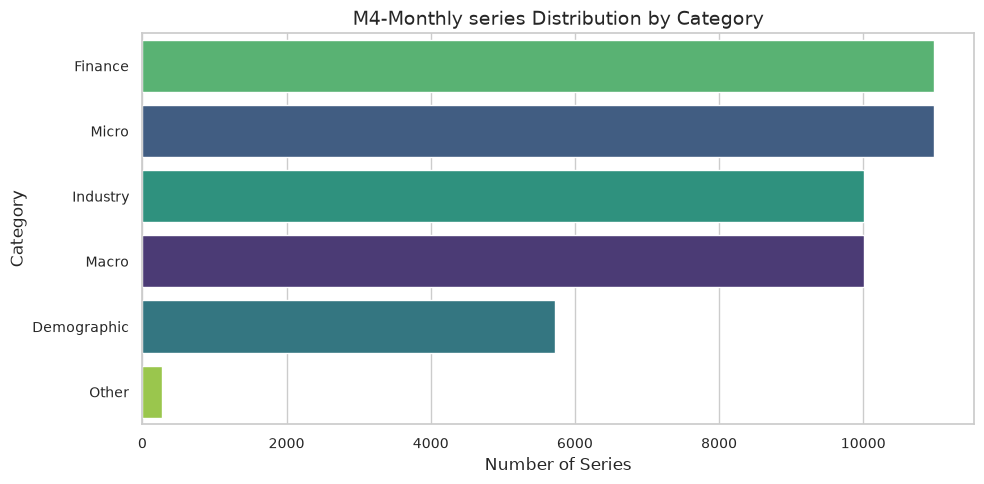

In [24]:
# Draw bar chart for category distribution
plt.figure(figsize=(10, 5))
category_col = 'category'
sns.countplot(data=monthly_info, 
              y=category_col, 
              hue=category_col, 
              order=monthly_info[category_col].value_counts().index, 
              palette='viridis', 
              legend=False)
plt.title("M4-Monthly series Distribution by Category")
plt.xlabel("Number of Series")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

<Axes: xlabel='category', ylabel='length'>

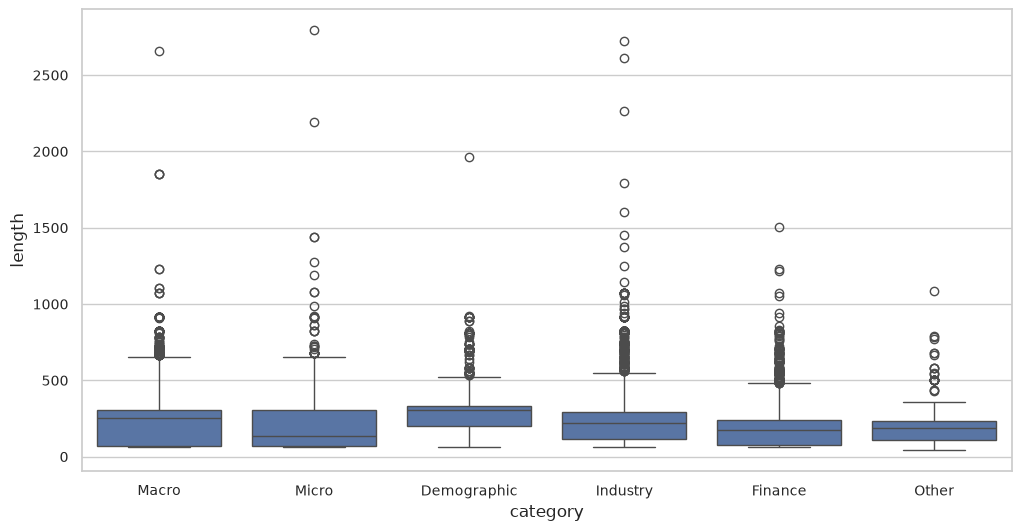

In [25]:
merged = lengths_df.merge(monthly_info, left_on="unique_id", right_on="M4id")
sns.boxplot(x="category", y="length", data=merged)

# 6. Trực quan hóa một số chuỗi thời gian ngẫu nhiên

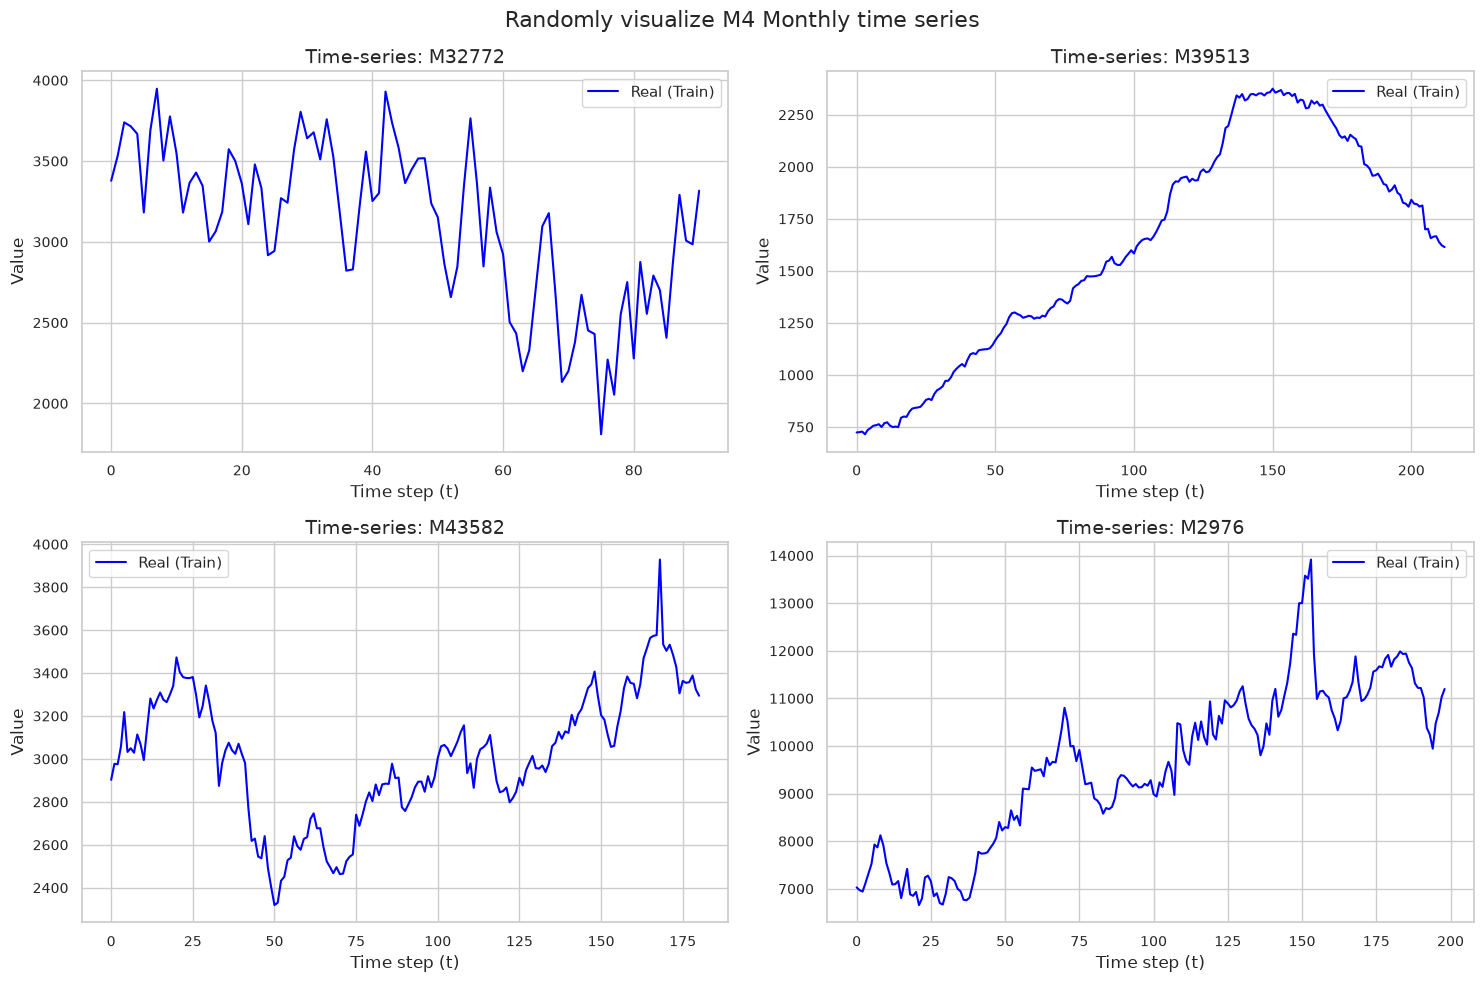

In [26]:
# Randomly select 4 series from train_wide to draw chart
np.random.seed(42)
random_ids = np.random.choice(train_wide['unique_id'].unique(), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, uid in enumerate(random_ids):
    # Extract the series and remove NaN
    series_data = train_wide[train_wide['unique_id']==uid].iloc[0, 1:].dropna().values

    axes[i].plot(series_data, label='Real (Train)', color='blue')
    axes[i].set_title(f"Time-series: {uid}")
    axes[i].set_xlabel("Time step (t)")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    
plt.suptitle("Randomly visualize M4 Monthly time series", fontsize=16)
plt.tight_layout()
plt.show()

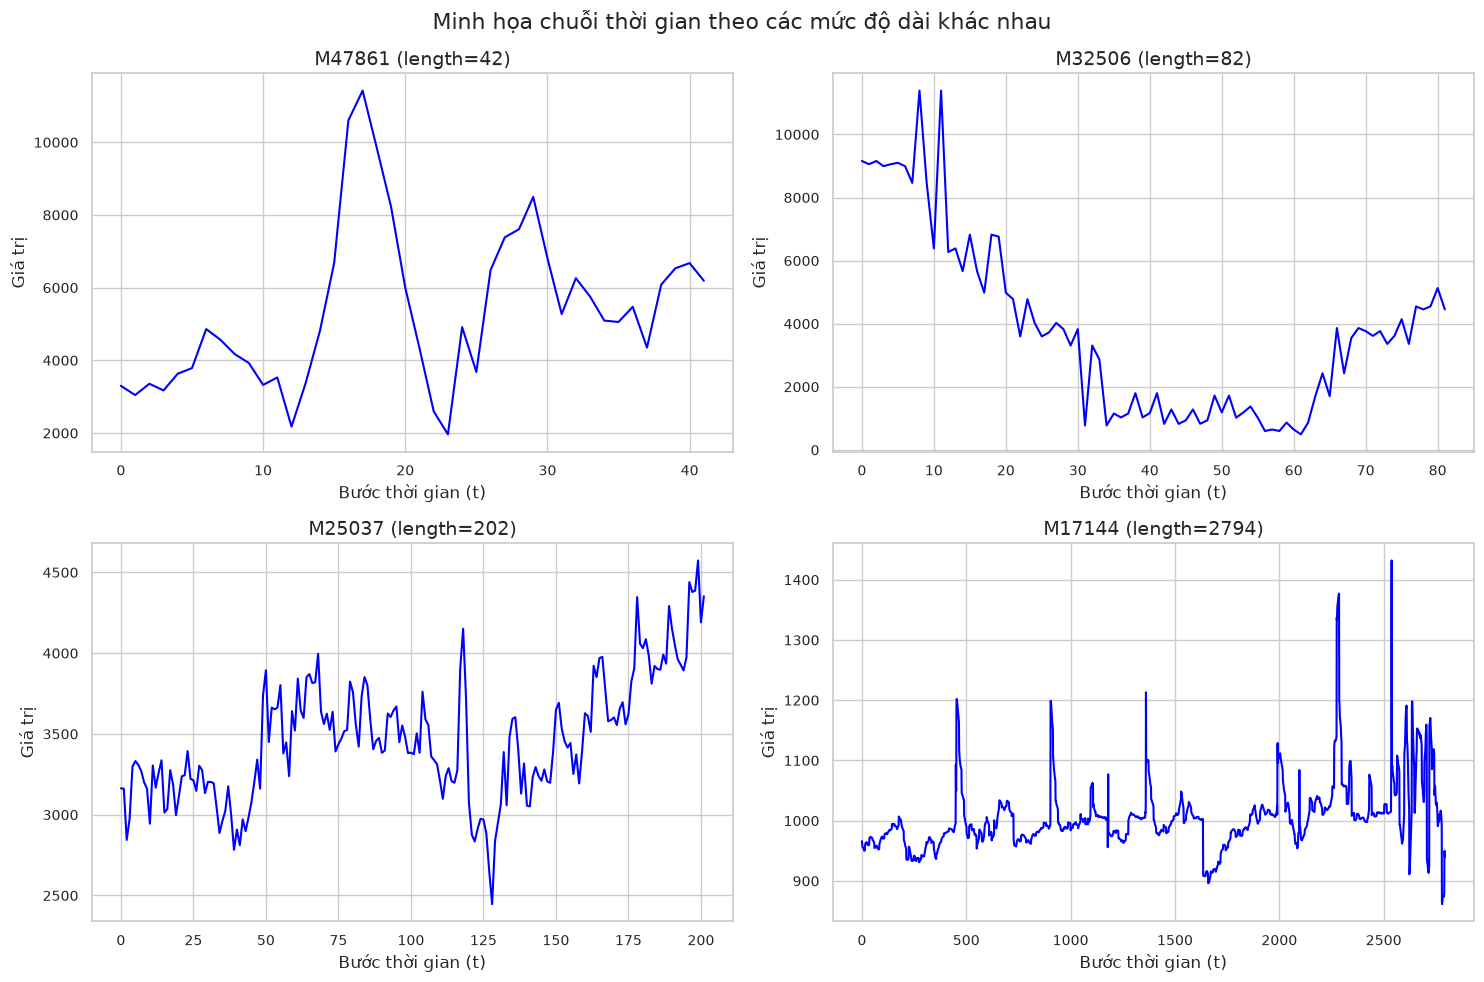

In [33]:
# Chọn có chủ đích: 1 series ngắn nhất, 1 trung vị, 1 dài nhất
sorted_lengths = lengths_df.sort_values('length').reset_index(drop=True)

sample_ids = [
    sorted_lengths.iloc[0]['unique_id'],                          # ngắn nhất
    sorted_lengths.iloc[len(sorted_lengths)//4]['unique_id'],      # nhóm short
    sorted_lengths.iloc[len(sorted_lengths)//2]['unique_id'],      # trung vị
    sorted_lengths.iloc[-1]['unique_id'],                          # dài nhất
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, uid in enumerate(sample_ids):
    series_data = train_wide[train_wide['unique_id'] == uid].iloc[0, 1:].dropna().values
    axes[i].plot(series_data, color='blue')
    axes[i].set_title(f"{uid} (length={len(series_data)})")
    axes[i].set_xlabel("Bước thời gian (t)")
    axes[i].set_ylabel("Giá trị")

plt.suptitle("Minh họa chuỗi thời gian theo các mức độ dài khác nhau", fontsize=16)
plt.tight_layout()
plt.show()

# 7. Phân tích tính Tự tương quan (Autocorrelation - ACF / PACF)

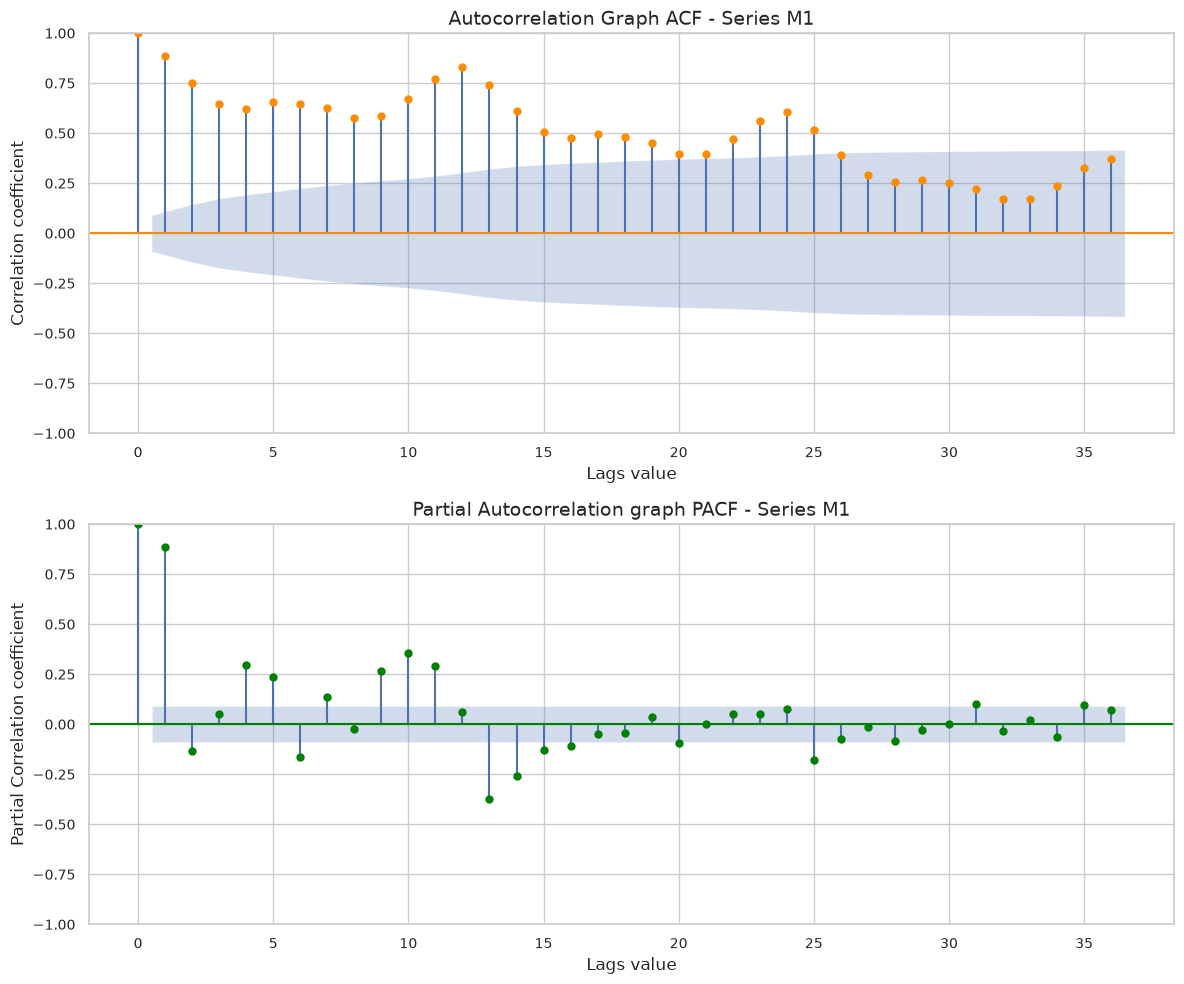

In [27]:
# Việc phân tích ACF/PACF giúp xác định chu kỳ mùa vụ và lựa chọn Lag Features khoa học hơn.
# Chúng ta sẽ phân tích trên một chuỗi cụ thể (ví dụ: chuỗi đầu tiên M1)
target_uid = 'M1'
m1_series = train_wide[train_wide['unique_id'] == target_uid].iloc[0, 1:].dropna().astype(float).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Vẽ biểu đồ ACF (Autocorrelation Function)
plot_acf(m1_series, lags=36, ax=ax1, color='darkorange')
ax1.set_title(f"Autocorrelation Graph ACF - Series {target_uid}")
ax1.set_xlabel("Lags value")
ax1.set_ylabel("Correlation coefficient")

# Vẽ biểu đồ PACF (Partial Autocorrelation Function)
plot_pacf(m1_series, lags=36, ax=ax2, color='green')
ax2.set_title(f"Partial Autocorrelation graph PACF - Series {target_uid}")
ax2.set_xlabel("Lags value")
ax2.set_ylabel("Partial Correlation coefficient")

plt.tight_layout()
plt.show()


# 8. Nhận xét và Đề xuất Hướng xử lý Dữ liệu (Dành cho báo cáo kỹ thuật)

In [34]:
print(f"""
==============================================================================
KẾT LUẬN & ĐỀ XUẤT CHO BƯỚC FEATURE ENGINEERING (src/features.py):
==============================================================================
1. Độ dài các chuỗi không đồng đều:
   - Tổng số series (đầy đủ, không sample): {len(lengths_df)}
   - Min/Max/Mean/Median length: {lengths_df['length'].min()} / \
{lengths_df['length'].max()} / {lengths_df['length'].mean():.1f} / \
{lengths_df['length'].median()}
   - Quartile: {dict(quantiles)}
   - Đề xuất ngưỡng lọc: MIN_LENGTH = {MIN_LENGTH}, MAX_LENGTH = {MAX_LENGTH}

2. Đặc trưng trễ (Lag Features):
   - ACF/PACF cho thấy tương quan cao ở lag 1, 2, 3 và lặp lại chu kỳ ở lag 12.
   - Đề xuất: tạo lag_1, lag_2, lag_3 (ngắn hạn) và lag_12 (mùa vụ hàng năm).

3. Thống kê trượt (Rolling Statistics):
   - Đề xuất cửa sổ 3, 6, 12 tháng. Bắt buộc shift(1) trước khi tính để
     tránh data leakage.

4. Tính mùa vụ (Date Features):
   - Không có ngày tháng thật -> giả lập cột 'ds' từ mốc cố định,
     trích xuất month/quarter/is_quarter_end.

5. Dữ liệu bất thường:
   - Series có giá trị âm: {negative_count}
   - Series có >30% giá trị bằng 0: {len(zero_heavy_ids)}
   - Cần quyết định: loại bỏ hay giữ lại các series này khi sampling.

6. Horizon test set: đã xác nhận = {horizon} (đúng chuẩn Monthly = 18).
==============================================================================
""")


KẾT LUẬN & ĐỀ XUẤT CHO BƯỚC FEATURE ENGINEERING (src/features.py):
1. Độ dài các chuỗi không đồng đều:
   - Tổng số series (đầy đủ, không sample): 48000
   - Min/Max/Mean/Median length: 42 / 2794 / 216.3 / 202.0
   - Quartile: {0.25: np.float64(82.0), 0.5: np.float64(202.0), 0.75: np.float64(306.0)}
   - Đề xuất ngưỡng lọc: MIN_LENGTH = 36, MAX_LENGTH = 400

2. Đặc trưng trễ (Lag Features):
   - ACF/PACF cho thấy tương quan cao ở lag 1, 2, 3 và lặp lại chu kỳ ở lag 12.
   - Đề xuất: tạo lag_1, lag_2, lag_3 (ngắn hạn) và lag_12 (mùa vụ hàng năm).

3. Thống kê trượt (Rolling Statistics):
   - Đề xuất cửa sổ 3, 6, 12 tháng. Bắt buộc shift(1) trước khi tính để
     tránh data leakage.

4. Tính mùa vụ (Date Features):
   - Không có ngày tháng thật -> giả lập cột 'ds' từ mốc cố định,
     trích xuất month/quarter/is_quarter_end.

5. Dữ liệu bất thường:
   - Series có giá trị âm: 0
   - Series có >30% giá trị bằng 0: 0
   - Cần quyết định: loại bỏ hay giữ lại các series này khi sampling.

6.